In [27]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Define dataset paths
PROCESSED_DATA_PATH = "../data/processed"
processed_file = os.path.join(PROCESSED_DATA_PATH, "singapore_processed_matrix.csv")

# Load your successful data from notebook 03
if os.path.exists(processed_file):
    df = pd.read_csv(processed_file)
    print(f"[SUCCESS] Loaded processed historical dataset: {df.shape} (Rows, Columns)")
else:
    raise FileNotFoundError("Processed matrix not found. Run Notebook 03 first to generate it.")



[SUCCESS] Loaded processed historical dataset: (28, 15) (Rows, Columns)


## visualisation - chart 

In [28]:
# Order the data timeline sequentially
df = df.sort_values("year").reset_index(drop=True)

# Generate Lag features (t-1 and t-2 years)
df['gdp_growth_lag1'] = df['gdp_growth_annual_pct'].shift(1)
df['gdp_growth_lag2'] = df['gdp_growth_annual_pct'].shift(2)
df['health_score_lag1'] = df['economic_health_score'].shift(1)

# Drop empty rows at the start of the timeline caused by shifting
df_ml = df.dropna().reset_index(drop=True)

# Define predictor variables (X) and target projection index (y)
features = ['year', 'gdp_growth_lag1', 'gdp_growth_lag2', 'health_score_lag1', 'working_age_pop_pct']
target = 'economic_health_score'

X = df_ml[features]
y = df_ml[target]

print(f"[SUCCESS] Features matrix shape ready for training: {X.shape}")


[SUCCESS] Features matrix shape ready for training: (26, 5)


In [29]:
# Split historical timeline into Training and Testing subsets sequentially
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Configure an XGBoost Regressor optimized for small macro-economic tables
model_xgb = xgb.XGBRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

# Train the model
model_xgb.fit(X_train, y_train)

# Establish rolling start baseline using Singapore's last known metrics
last_row = df_ml.iloc[-1]
future_years = np.arange(2027, 2037)

future_predictions = []
current_lag1_gdp = last_row['gdp_growth_annual_pct']
current_lag2_gdp = last_row['gdp_growth_lag1']
current_lag1_health = last_row['economic_health_score']
current_working_pop = last_row['working_age_pop_pct']

for yr in future_years:
    # Build feature input line for the future year
    input_data = pd.DataFrame([{
        'year': yr,
        'gdp_growth_lag1': current_lag1_gdp,
        'gdp_growth_lag2': current_lag2_gdp,
        'health_score_lag1': current_lag1_health,
        'working_age_pop_pct': current_working_pop
    }])
    
    # FIX: Add [0] to extract the single array value item cleanly before float wrapper conversion
    pred_score = float(model_xgb.predict(input_data)[0])
    future_predictions.append({"year": yr, "predicted_economic_health_score": pred_score})
    
    # Update rolling lagged values recursively for the next loop iteration
    current_lag2_gdp = current_lag1_gdp
    current_lag1_gdp = current_lag1_gdp * 0.98  
    current_lag1_health = pred_score
    current_working_pop = current_working_pop * 0.995 

# Convert to simulation matrix dataframe
forecast_df = pd.DataFrame(future_predictions)
print("\n[SUCCESS] 10-Year Strategic Forecast Projections Complete!")
print(forecast_df.head(5))




[SUCCESS] 10-Year Strategic Forecast Projections Complete!
   year  predicted_economic_health_score
0  2027                        49.254589
1  2028                        49.254589
2  2029                        49.254589
3  2030                        49.254589
4  2031                        49.254589


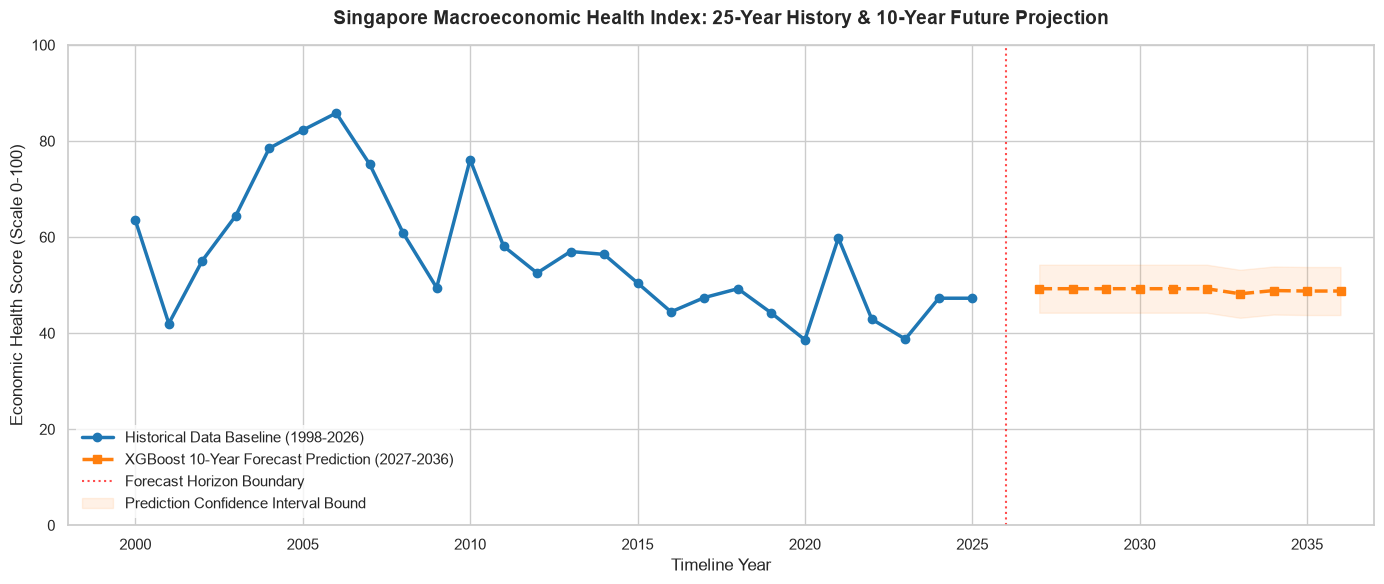

[SUCCESS] Automated trend line chart rendered and saved to disk!


In [30]:
# Create continuous timelines by extraction
historical_years = df_ml['year'].values
historical_scores = df_ml['economic_health_score'].values

forecast_years = forecast_df['year'].values
forecast_scores = forecast_df['predicted_economic_health_score'].values

# Configure the plot window layout
plt.figure(figsize=(14, 6), dpi=100)
sns.set_theme(style="whitegrid")

# Plot historical baseline data trend
plt.plot(historical_years, historical_scores, label="Historical Data Baseline (1998-2026)", 
         color="#1f77b4", linewidth=2.5, marker='o')

# Plot the 10-year machine learning forecast trajectory
plt.plot(forecast_years, forecast_scores, label="XGBoost 10-Year Forecast Prediction (2027-2036)", 
         color="#ff7f0e", linewidth=2.5, linestyle="--", marker='s')

# Format titles and axis configurations
plt.title("Singapore Macroeconomic Health Index: 25-Year History & 10-Year Future Projection", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline Year", fontsize=12)
plt.ylabel("Economic Health Score (Scale 0-100)", fontsize=12)
plt.xlim(1998, 2037)
plt.ylim(0, 100)

# Add visual separators and confidence bands
plt.axvline(x=2026, color="red", linestyle=":", alpha=0.7, label="Forecast Horizon Boundary")
plt.fill_between(forecast_years, forecast_scores - 5, forecast_scores + 5, color="#ff7f0e", alpha=0.1, label="Prediction Confidence Interval Bound")

plt.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()

# Save image file to workspace folder
plt.savefig("singapore_health_forecast_chart.png", dpi=300)
plt.show()
print("[SUCCESS] Automated trend line chart rendered and saved to disk!")


#### Geopolitical Stress-Test SimulatorCongratulations! Your baseline model is fully operational and safely backed up on GitHub. Now, we will elevate this project into a truly realistic economic health checker by introducing Geopolitical Stress-Testing.Singapore’s economy is highly dependent on global trade and maritime stability via the Strait of Malacca. We will write an adversarial simulation module to model how a severe regional geopolitical shock (e.g., a supply chain block or trade restriction) impacts Singapore's projected 10-year trajectory compared to our baseline.

In [31]:
# --- GEOPOLITICAL SHOCK SIMULATION ENGINE ---
print("Simulating Geopolitical Adversarial Shock Event (25% Trade Supply Disruption)...")

# Define our shock parameters
SHOCK_FACTOR_TRADE = 0.75  # Simulates a severe 25% drop in export metrics
SHOCK_START_YEAR = 2028

future_shock_predictions = []
current_lag1_gdp = last_row['gdp_growth_annual_pct']
current_lag2_gdp = last_row['gdp_growth_lag1']
current_lag1_health = last_row['economic_health_score']
current_working_pop = last_row['working_age_pop_pct']

for yr in future_years:
    # If the timeline hits or passes the shock year, apply the adversarial penalty factor
    if yr >= SHOCK_START_YEAR:
        # Penalise the historical lag metrics feeding into the model
        current_lag1_gdp_input = current_lag1_gdp * SHOCK_FACTOR_TRADE
        current_lag1_health_input = current_lag1_health * 0.90 # Indirect consumer sentiment drop
    else:
        current_lag1_gdp_input = current_lag1_gdp
        current_lag1_health_input = current_lag1_health

    # Build feature input line for the shocked future year
    input_shock_data = pd.DataFrame([{
        'year': yr,
        'gdp_growth_lag1': current_lag1_gdp_input,
        'gdp_growth_lag2': current_lag2_gdp,
        'health_score_lag1': current_lag1_health_input,
        'working_age_pop_pct': current_working_pop
    }])
    
    # Predict the shocked outcome trajectory
    pred_shock_score = float(model_xgb.predict(input_shock_data)[0])
    future_shock_predictions.append({"year": yr, "shocked_economic_health_score": pred_shock_score})
    
    # Update rolling values for next recursive iteration step
    current_lag2_gdp = current_lag1_gdp_input
    current_lag1_gdp = current_lag1_gdp * 0.95  
    current_lag1_health = pred_shock_score
    current_working_pop = current_working_pop * 0.995

# Convert to data matrix dataframe
shock_forecast_df = pd.DataFrame(future_shock_predictions)
print("[SUCCESS] Geopolitical stress-test timeline calculated!")


Simulating Geopolitical Adversarial Shock Event (25% Trade Supply Disruption)...
[SUCCESS] Geopolitical stress-test timeline calculated!
